**LIBRARIES**

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import heapq
import statistics
import collections

**DATA LOADING**

In [2]:
def load_data():
    G = nx.read_edgelist('/content/drive/MyDrive/Explo/facebook_combined.txt', create_using = nx.Graph(), nodetype = int)
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    print("Density:", nx.density(G))
    print("Connected Components:", nx.number_connected_components(G))
    return G
G = load_data()

Nodes: 4039
Edges: 88234
Density: 0.010819963503439287
Connected Components: 1


**SEED SELECTION STRATEGIES**

In [3]:
class Seed_Selection:
    def __init__(self, G, k):
        self.Graph = G
        self.seed_size = k
        self.degree_dict = dict(self.Graph.degree())
        self.betweenness_dict = nx.betweenness_centrality(self.Graph)
        self.closeness_dict = nx.closeness_centrality(self.Graph)

    def random_seeds(self):
        return set(random.sample(list(self.Graph.nodes()), self.seed_size))

    def degree_based(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.degree_dict,
            key=self.degree_dict.get
        )
        return set(top_k)

    def betweenness_seeds(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.betweenness_dict,
            key=self.betweenness_dict.get
        )
        return set(top_k)

    def closeness_seeds(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.closeness_dict,
            key=self.closeness_dict.get
        )
        return set(top_k)

In [4]:
def select_competitive_seeds(graph, k_A=5, k_B=5, strategy_A='degree', strategy_B='random'):

    seeds_A = []
    seeds_B = []

    if strategy_A == 'degree':
        sorted_nodes = sorted(graph.degree, key=lambda x: x[1], reverse=True)
        seeds_A = [node for node, degree in sorted_nodes[:k_A]]
    elif strategy_A == 'random':
        seeds_A = random.sample(list(graph.nodes()), k_A)


    available_nodes = [node for node in graph.nodes() if node not in seeds_A]

    if strategy_B == 'degree':
        available_degrees = [(node, graph.degree(node)) for node in available_nodes]
        sorted_available = sorted(available_degrees, key=lambda x: x[1], reverse=True)
        seeds_B = [node for node, degree in sorted_available[:k_B]]

    elif strategy_B == 'random':
        seeds_B = random.sample(available_nodes, k_B)

    return seeds_A, seeds_B

**MONTE CARLO SIMULATIONS**

In [5]:
def run_multiple_simulations(G, Model, seeds_A, seeds_B, runs=50, **model_params):

    spreads_A = []
    spreads_B = []

    for i in range(runs):
        model = Model(G, seeds_A, seeds_B, **model_params)
        history = model.run(steps=10)

        spreads_A.append(history['A'][-1])
        spreads_B.append(history['B'][-1])

    return np.mean(spreads_A), np.mean(spreads_B)

**GRAPHS**

In [6]:
#Diffusion Curve
def plot_diffusion_curve(history):
    plt.figure()

    plt.plot(history['A'], label="Cascade A")
    plt.plot(history['B'], label="Cascade B")
    if 'Neutral' in history:
        plt.plot(history['Neutral'], label="Neutral")

    plt.xlabel("Time Step")
    plt.ylabel("Number of Nodes")
    plt.title("Competitive Diffusion Over Time")
    plt.legend()
    plt.show()


#Final Spread
def plot_final_spread(history):
    final_A = history['A'][-1]
    final_B = history['B'][-1]

    plt.figure()
    plt.bar(["Cascade A", "Cascade B"], [final_A, final_B])

    plt.ylabel("Number of Adopters")
    plt.title("Final Adoption Spread")
    plt.show()


#Network States
def plot_network_state(G, states):
    colors = []

    for node in G.nodes():
        if states[node] == 1:
            colors.append("blue")
        elif states[node] == 2:
            colors.append("red")
        else:
            colors.append("gray")

    pos = nx.spring_layout(G)

    plt.figure()
    nx.draw(G, pos, node_color=colors, node_size=80)
    plt.title("Network Adoption State")
    plt.show()

In [7]:
#Analyze Seed Sizes
def analyze_seed_sizes(G, model_class, seed_sizes=[2,4,6,8,10], runs=20, **model_params):

    spread_A = []
    spread_B = []

    for k in seed_sizes:

        seed_selector = Seed_Selection(G, k)

        seeds_A = seed_selector.degree_based()
        seeds_B = seed_selector.random_seeds()

        A,B = run_multiple_simulations(G, model_class, seeds_A, seeds_B, runs=runs, **model_params)

        spread_A.append(A)
        spread_B.append(B)

    plt.plot(seed_sizes, spread_A, marker='o', label="Cascade A")
    plt.plot(seed_sizes, spread_B, marker='o', label="Cascade B")

    plt.xlabel("Seed Size")
    plt.ylabel("Average Final Spread")
    plt.title("Effect of Seed Size on Diffusion")

    plt.legend()
    plt.show()

In [12]:
#Analyze seed strategies
def seed_strategies(G, model_class, k, runs=20, **model_params):

    seed_selector = Seed_Selection(G, k)

    seeds_A = seed_selector.random_seeds()
    seeds_B = seed_selector.random_seeds()

    A1, B1 = run_multiple_simulations(G, model_class, seeds_A, seeds_B, runs=runs, **model_params)

    seeds_A_hd = seed_selector.degree_based()

    A2, B2 = run_multiple_simulations(G, model_class, seeds_A_hd, seeds_B, runs=runs, **model_params)

    plt.bar(["Random A", "High Degree A"], [A1, A2])

    plt.ylabel("Average Adoption of A")
    plt.title("Effect of Seed Strategy")

    plt.show()

**MODELS**

*Distance Based Model*

In [8]:
class DistanceBasedModel:
    def __init__(self, G, seeds_A, seeds_B):
        self.graph = G
        self.states = {node: 0 for node in G.nodes()}

        for node in seeds_A:
            self.states[node] = 1
        for node in seeds_B:
            self.states[node] = 2

        self.history = {'A': [], 'B': [], 'Neutral': []}
        self.record_history()

    def record_history(self):
        vals = list(self.states.values())
        self.history['Neutral'].append(vals.count(0))
        self.history['A'].append(vals.count(1))
        self.history['B'].append(vals.count(2))

    def step(self):
        new_states = self.states.copy()

        A_sources = [n for n, s in self.states.items() if s == 1]
        B_sources = [n for n, s in self.states.items() if s == 2]

        if not A_sources and not B_sources:
            return

        dist_A = nx.multi_source_dijkstra_path_length(self.graph, A_sources)
        dist_B = nx.multi_source_dijkstra_path_length(self.graph, B_sources)

        for u in self.graph.nodes():
            if self.states[u] != 0:
                continue

            d_A = dist_A.get(u, float('inf'))
            d_B = dist_B.get(u, float('inf'))

            if d_A == float('inf') and d_B == float('inf'):
                continue

            V_A = 1.0 / d_A if d_A > 0 else 0
            V_B = 1.0 / d_B if d_B > 0 else 0

            if V_A + V_B == 0:
                continue

            prob_A = V_A / (V_A + V_B)

            if random.random() < prob_A:
                new_states[u] = 1
            else:
                new_states[u] = 2

        self.states = new_states
        self.record_history()

    def run(self, steps=10):
        for _ in range(steps):
            self.step()
        return self.history

In [52]:
seeds_A, seeds_B = select_competitive_seeds(G, 5, 5, 'degree', 'random')

model = DistanceBasedModel(G, seeds_A, seeds_B)
history = model.run(steps=10)

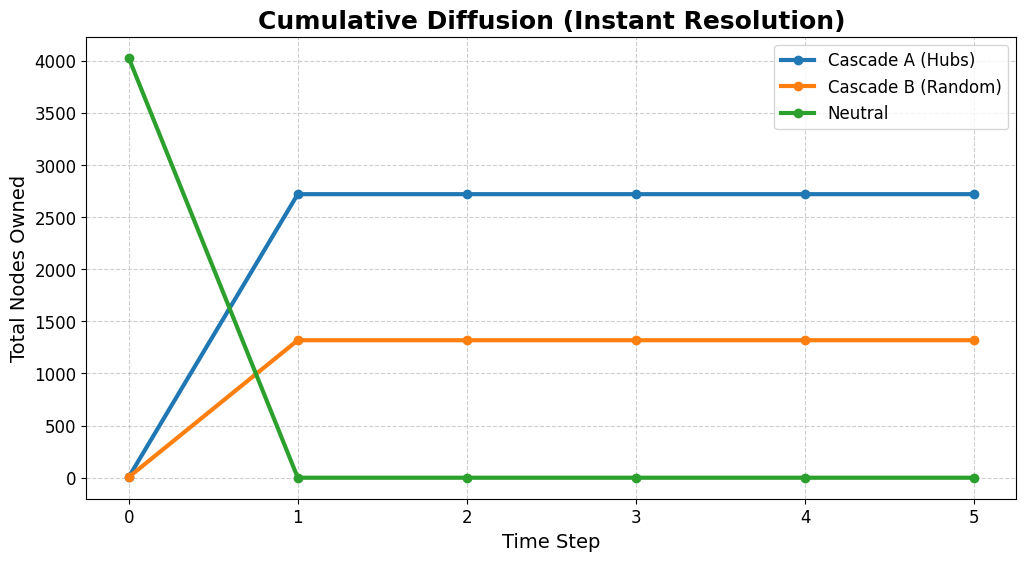

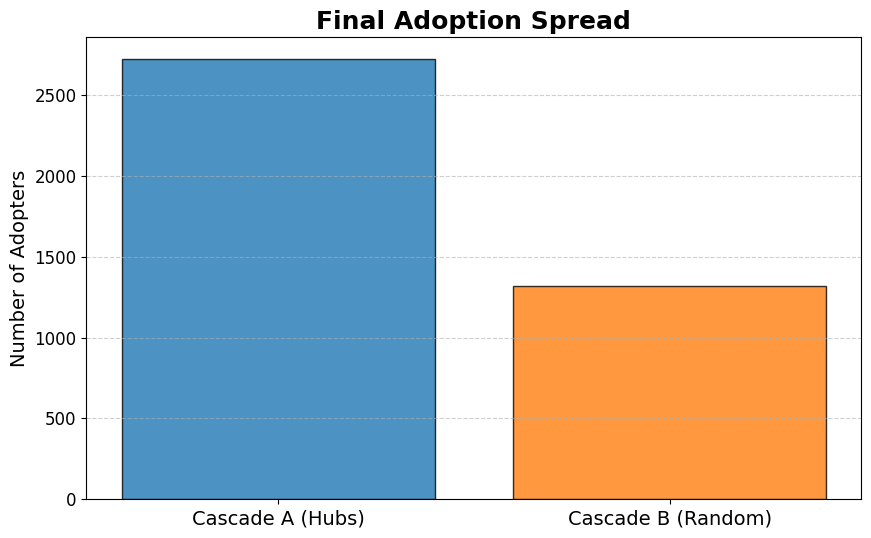

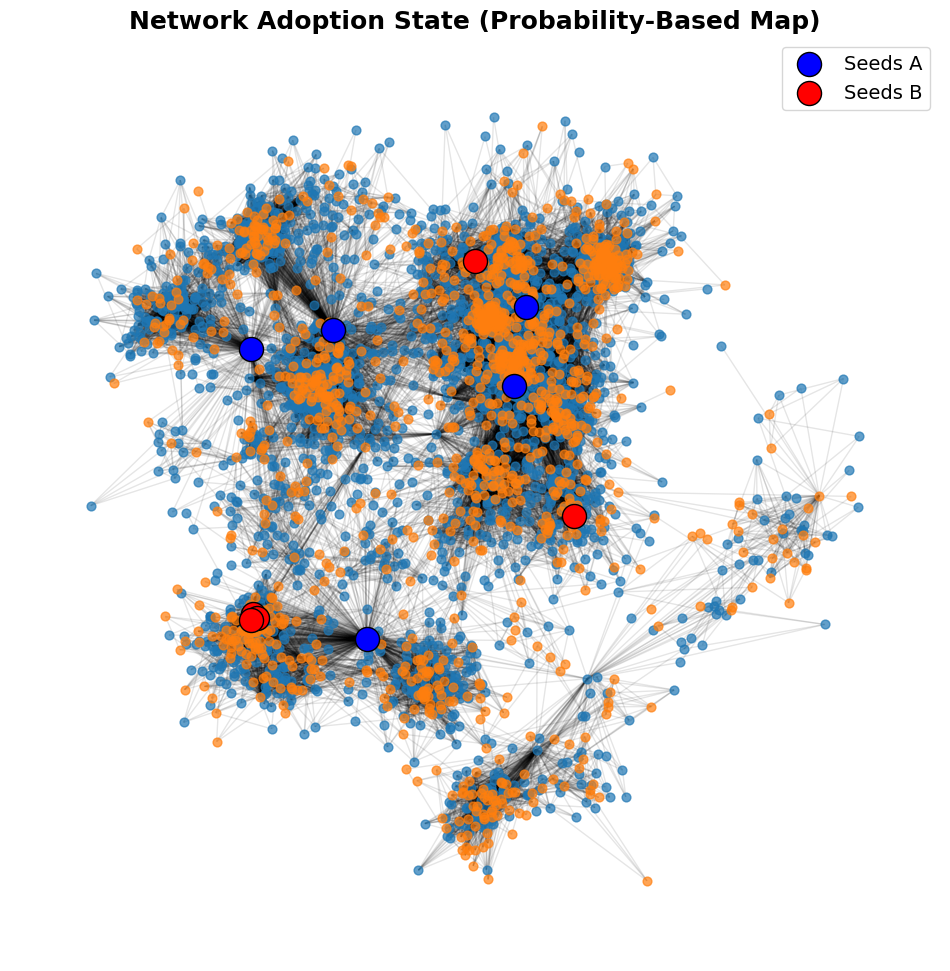

In [9]:
steps_range = range(len(history['A']))


plt.figure(figsize=(12, 6))
plt.plot(steps_range, history['A'], label='Cascade A (Hubs)', color='#1f77b4', linewidth=3, marker='o')
plt.plot(steps_range, history['B'], label='Cascade B (Random)', color='#ff7f0e', linewidth=3, marker='o')
plt.plot(steps_range, history['Neutral'], label='Neutral', color='#2ca02c', linewidth=3, marker='o')
plt.title('Cumulative Diffusion (Instant Resolution)', fontsize=18, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Total Nodes Owned', fontsize=14)
plt.xticks(steps_range, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(10, 6))
plt.bar(['Cascade A (Hubs)', 'Cascade B (Random)'],
        [history['A'][-1], history['B'][-1]],
        color=['#1f77b4', '#ff7f0e'], edgecolor='black', alpha=0.8)
plt.title('Final Adoption Spread', fontsize=18, fontweight='bold')
plt.ylabel('Number of Adopters', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(12, 12))
plt.title('Network Adoption State (Probability-Based Map)', fontsize=18, fontweight='bold')

pos = nx.spring_layout(G, seed=42)


nodes_A = [n for n, s in model.states.items() if s == 1 and n not in seeds_A]
nodes_B = [n for n, s in model.states.items() if s == 2 and n not in seeds_B]
neutral = [n for n, s in model.states.items() if s == 0]


nx.draw_networkx_nodes(G, pos, nodelist=nodes_A, node_color='#1f77b4', node_size=40, alpha=0.7)
nx.draw_networkx_nodes(G, pos, nodelist=nodes_B, node_color='#ff7f0e', node_size=40, alpha=0.7)
if neutral:
    nx.draw_networkx_nodes(G, pos, nodelist=neutral, node_color='#2ca02c', node_size=40, alpha=0.5)

nx.draw_networkx_nodes(G, pos, nodelist=seeds_A, node_color='blue', node_size=300, edgecolors='black', label='Seeds A')
nx.draw_networkx_nodes(G, pos, nodelist=seeds_B, node_color='red', node_size=300, edgecolors='black', label='Seeds B')

nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.legend(scatterpoints=1, fontsize=14)
plt.axis('off')
plt.show()

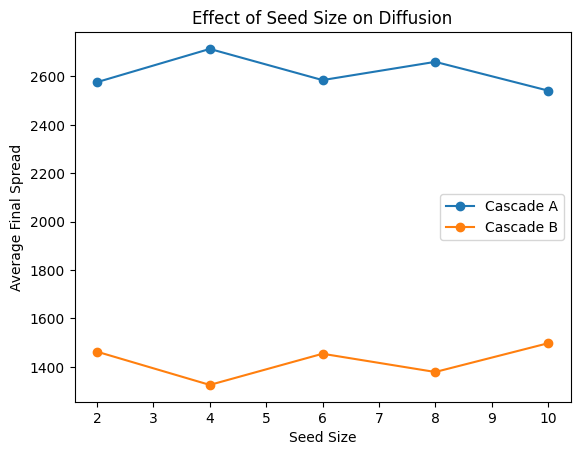

In [10]:
analyze_seed_sizes(G, DistanceBasedModel, runs=10)

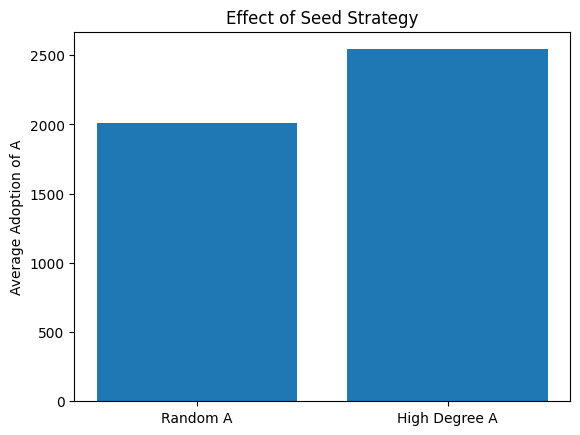

In [13]:
seed_strategies(G, DistanceBasedModel, 10, runs=10)

*Wave Propagation Model*

In [20]:
class WavePropagationModel:
    def __init__(self, G, seeds_A, seeds_B):
        self.graph = G
        self.states = {node: 0 for node in G.nodes()}

        self.queue_A = collections.deque([(n, 0) for n in seeds_A])
        self.queue_B = collections.deque([(n, 0) for n in seeds_B])

        for n in seeds_A:
            self.states[n] = 1
        for n in seeds_B:
            self.states[n] = 2

        self.current_time = 0

        self.history = {
            'A': [], 'B': [], 'Neutral': [],
            'New_A': [len(seeds_A)],
            'New_B': [len(seeds_B)],
            'Collisions': [0]
        }
        self.record_history()

    def record_history(self):
        vals = list(self.states.values())
        self.history['Neutral'].append(vals.count(0))
        self.history['A'].append(vals.count(1))
        self.history['B'].append(vals.count(2))

    def step(self):
        self.current_time += 1
        attacks = {}


        while self.queue_A and self.queue_A[0][1] < self.current_time:
            u, _ = self.queue_A.popleft()
            for v in self.graph.neighbors(u):
                if self.states[v] == 0:
                    if v not in attacks: attacks[v] = {'A': 0, 'B': 0}
                    attacks[v]['A'] += 1


        while self.queue_B and self.queue_B[0][1] < self.current_time:
            u, _ = self.queue_B.popleft()
            for v in self.graph.neighbors(u):
                if self.states[v] == 0:
                    if v not in attacks: attacks[v] = {'A': 0, 'B': 0}
                    attacks[v]['B'] += 1


        collisions_this_step = sum(1 for counts in attacks.values() if counts['A'] > 0 and counts['B'] > 0)
        new_a_count = 0
        new_b_count = 0


        for v, counts in attacks.items():
            prob_A = counts['A'] / (counts['A'] + counts['B'])

            if random.random() < prob_A:
                self.states[v] = 1
                self.queue_A.append((v, self.current_time))
                new_a_count += 1
            else:
                self.states[v] = 2
                self.queue_B.append((v, self.current_time))
                new_b_count += 1


        self.history['Collisions'].append(collisions_this_step)
        self.history['New_A'].append(new_a_count)
        self.history['New_B'].append(new_b_count)
        self.record_history()

    def run(self, steps=15):
        for _ in range(steps):
            if not self.queue_A and not self.queue_B:
                break
            self.step()
        return self.history


In [49]:
seeds_A, seeds_B = select_competitive_seeds(G, k_A=10, k_B=10, strategy_A='degree', strategy_B='degree')


model2 = WavePropagationModel(G, seeds_A, seeds_B)

history = model2.run(steps=10)

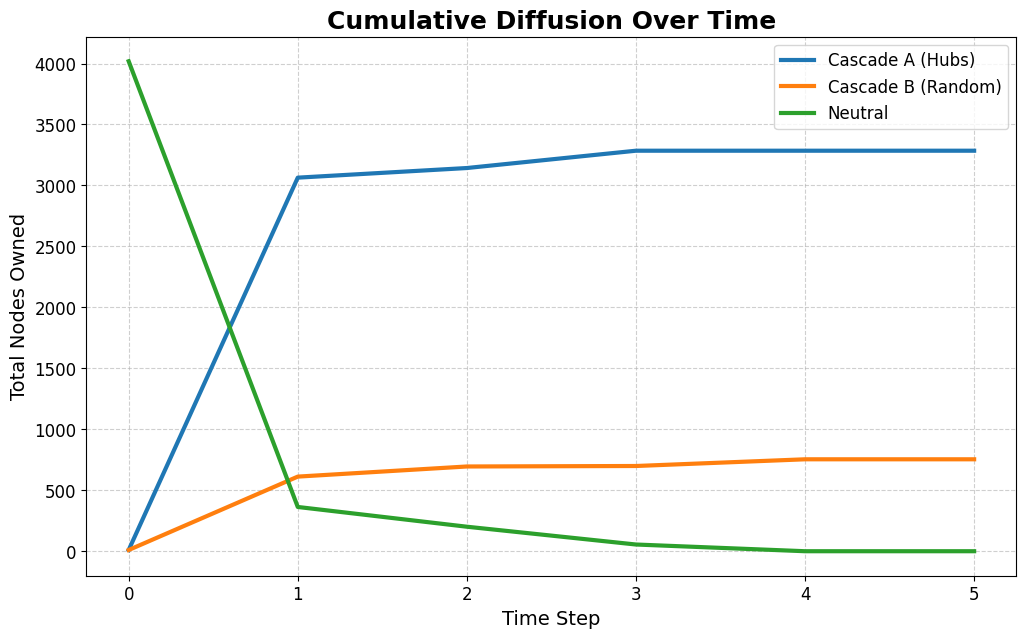

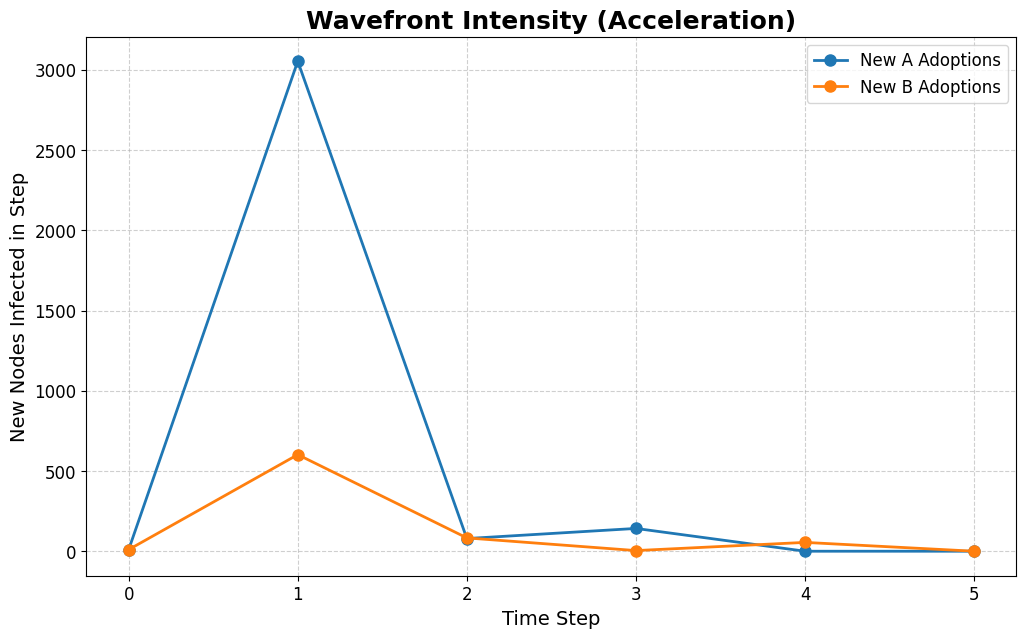

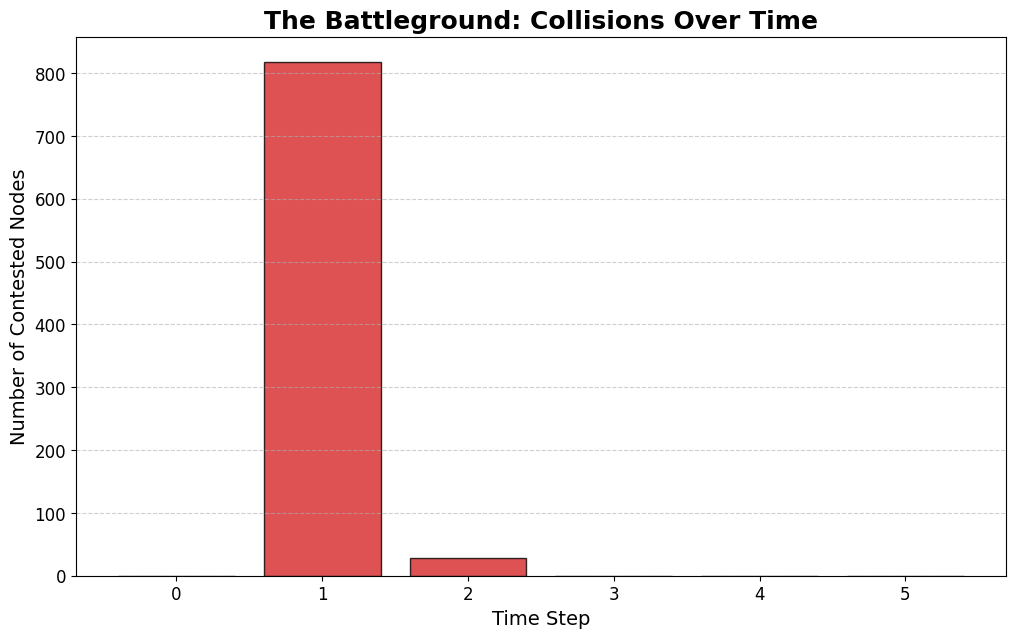

In [25]:
steps = range(len(history['A']))

plt.figure(figsize=(12, 7))
plt.plot(steps, history['A'], label='Cascade A (Hubs)', color='#1f77b4', linewidth=3)
plt.plot(steps, history['B'], label='Cascade B (Random)', color='#ff7f0e', linewidth=3)
plt.plot(steps, history['Neutral'], label='Neutral', color='#2ca02c', linewidth=3)
plt.title('Cumulative Diffusion Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Total Nodes Owned', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(12, 7))
plt.plot(steps, history['New_A'], label='New A Adoptions', color='#1f77b4', marker='o', markersize=8, linewidth=2)
plt.plot(steps, history['New_B'], label='New B Adoptions', color='#ff7f0e', marker='o', markersize=8, linewidth=2)
plt.title('Wavefront Intensity (Acceleration)', fontsize=18, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('New Nodes Infected in Step', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(12, 7))
plt.bar(steps, history['Collisions'], color='#d62728', alpha=0.8, edgecolor='black')
plt.title('The Battleground: Collisions Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Number of Contested Nodes', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

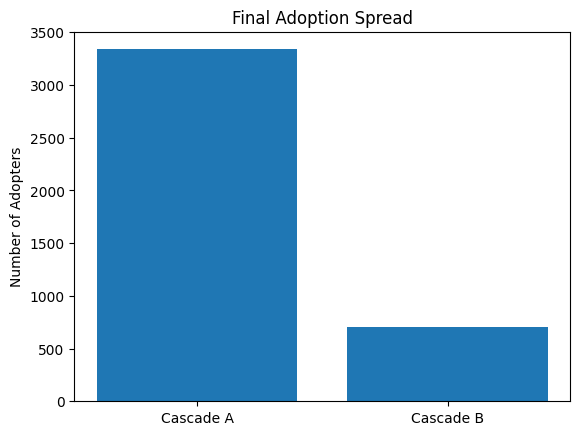

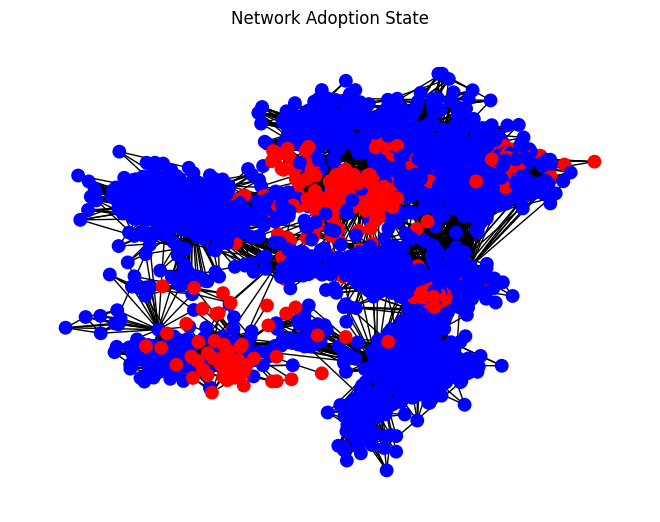

In [22]:
plot_final_spread(history)
plot_network_state(G, model2.states)

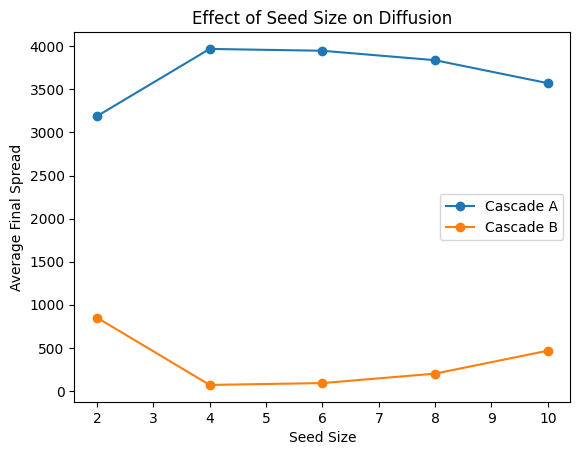

In [27]:
analyze_seed_sizes(G, WavePropagationModel, runs=10)

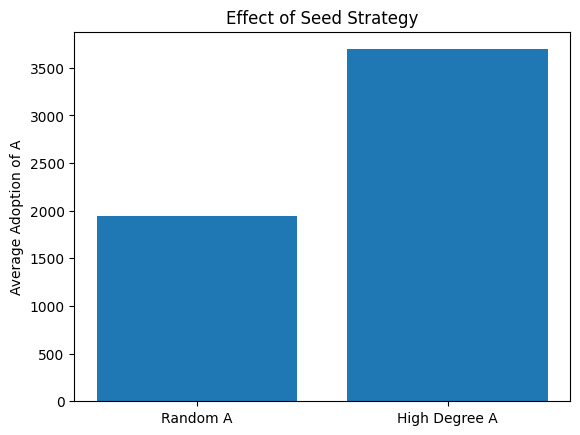

In [28]:
seed_strategies(G, WavePropagationModel, 10, runs=10)

*Separate Threshold*

In [42]:
class SeparatedThresholdModel:
    def __init__(self, G, seeds_A, seeds_B,
                 low=0.1, high=0.04):

        self.graph = G


        self.threshold_A = {v: random.uniform(low, high) for v in G.nodes()}
        self.threshold_B = {v: random.uniform(low, high) for v in G.nodes()}

        self.weights_A = {}
        self.weights_B = {}

        for u in G.nodes():
            neighbors = list(G.neighbors(u))
            if len(neighbors) == 0:
                continue
            w = 1.0 / len(neighbors)
            for v in neighbors:
                self.weights_A[(u, v)] = w
                self.weights_B[(u, v)] = w


        self.states = {node: 0 for node in G.nodes()}

        for n in seeds_A:
            self.states[n] = 1
        for n in seeds_B:
            self.states[n] = 2

        self.history = {'Inactive': [], 'A': [], 'B': []}
        self.record_history()

    def record_history(self):
        vals = list(self.states.values())
        self.history['Inactive'].append(vals.count(0))
        self.history['A'].append(vals.count(1))
        self.history['B'].append(vals.count(2))

    def step(self):
        new_states = self.states.copy()

        inactive_nodes = [n for n, s in self.states.items() if s == 0]

        for y in inactive_nodes:

            influence_A = 0
            influence_B = 0

            for x in self.graph.neighbors(y):
                if self.states[x] == 1:
                    influence_A += self.weights_A.get((y, x), 0)
                elif self.states[x] == 2:
                    influence_B += self.weights_B.get((y, x), 0)

            activate_A = influence_A >= self.threshold_A[y]
            activate_B = influence_B >= self.threshold_B[y]


            if activate_A and not activate_B:
                new_states[y] = 1

            elif activate_B and not activate_A:
                new_states[y] = 2

            elif activate_A and activate_B:

                if random.random() < 0.5:
                    new_states[y] = 1
                else:
                    new_states[y] = 2

        self.states = new_states
        self.record_history()

    def run(self, steps=50):
        for _ in range(steps):
            prev_total = self.history['A'][-1] + self.history['B'][-1]
            self.step()
            new_total = self.history['A'][-1] + self.history['B'][-1]
            if new_total == prev_total:
                break
        return self.history

In [44]:
seeds_A, seeds_B = select_competitive_seeds(G, k_A=10, k_B=10, strategy_A='degree', strategy_B='degree')



model3 = SeparatedThresholdModel(G, seeds_A, seeds_B)

history = model3.run(steps=10)

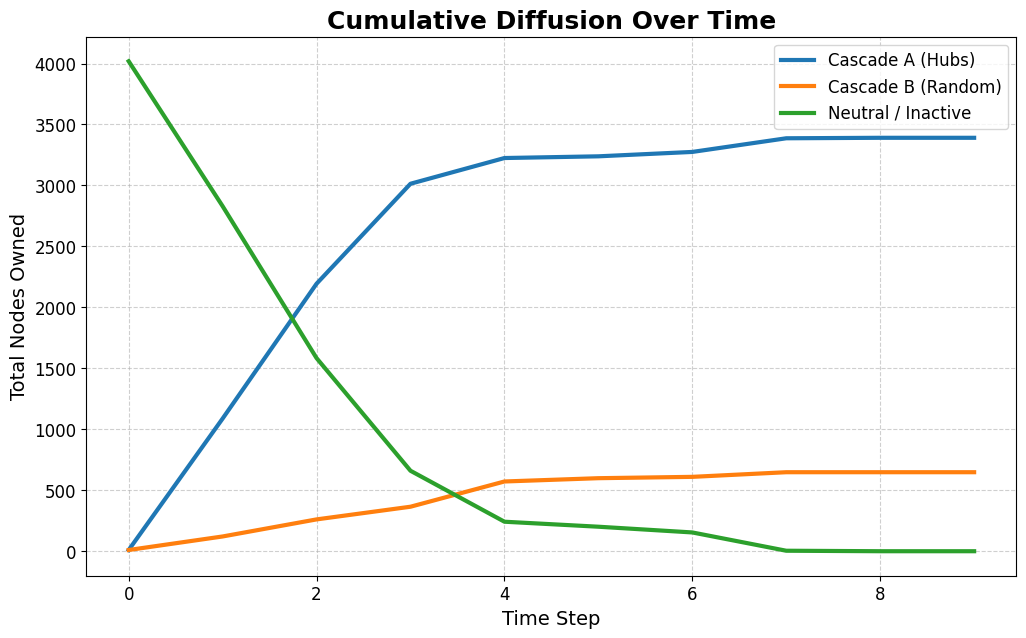

In [46]:
steps = range(len(history['A']))

plt.figure(figsize=(12, 7))
plt.plot(steps, history['A'], label='Cascade A (Hubs)', color='#1f77b4', linewidth=3)
plt.plot(steps, history['B'], label='Cascade B (Random)', color='#ff7f0e', linewidth=3)
plt.plot(steps, history['Inactive'], label='Neutral / Inactive', color='#2ca02c', linewidth=3)
plt.title('Cumulative Diffusion Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Total Nodes Owned', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

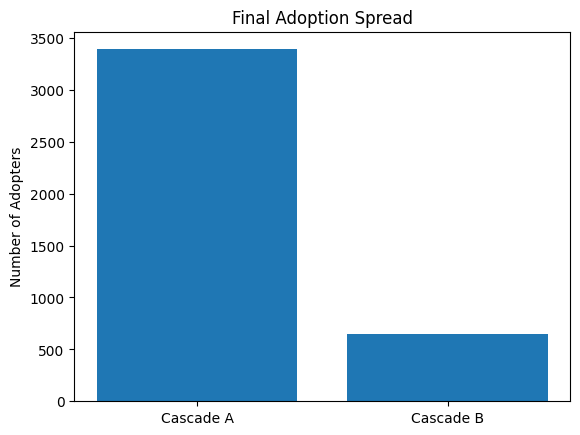

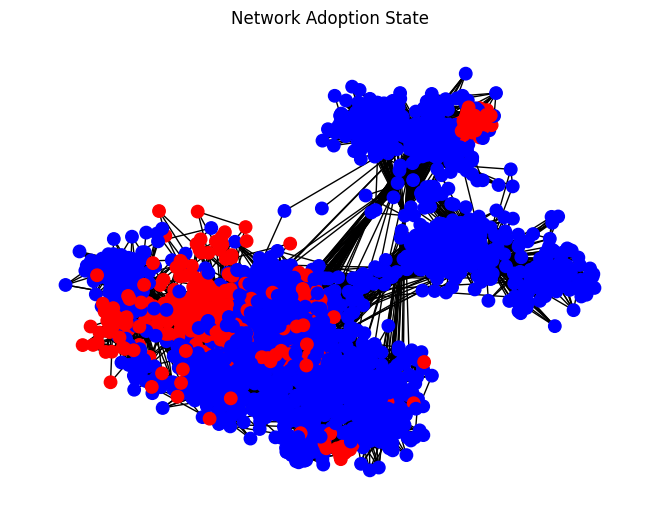

In [47]:
plot_final_spread(history)
plot_network_state(G, model3.states)

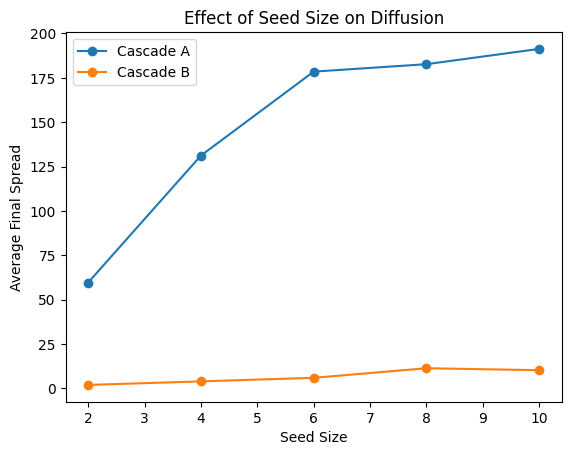

In [ ]:
analyze_seed_sizes(G, SeparatedThresholdModel, runs=10)

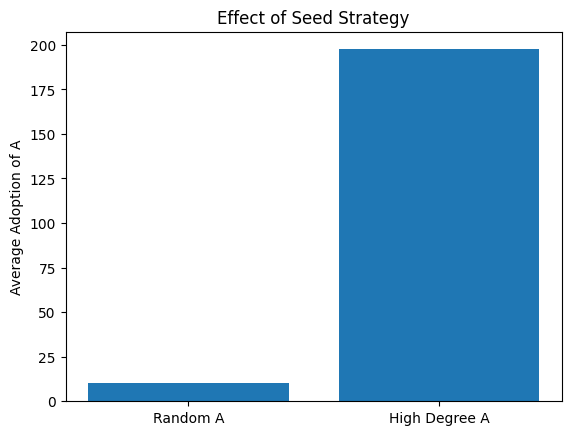

In [ ]:
seed_strategies(G, SeparatedThresholdModel, 10, runs=10)

*Weight Proportional Threshold Model*

In [29]:
def assign_thresholds(G, low=0.1, high=0.5):
    return {node: random.uniform(low, high) for node in G.nodes()}

def assign_weights(G):
    weights = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if not neighbors: continue
        raw_weights = {neighbor: random.random() for neighbor in neighbors}
        total = sum(raw_weights.values())
        for neighbor in neighbors:
            weights[(neighbor, node)] = raw_weights[neighbor] / total
    return weights


In [30]:
class CompetitiveWeightedThreshold:
    def __init__(self, G, SA, SB, low=0.1, high=0.5):
        self.graph = G
        self.thresholds = assign_thresholds(G, low, high)
        self.weights = assign_weights(G)

        self.states = {node: 0 for node in G.nodes()}
        for node in SA: self.states[node] = 1
        for node in SB: self.states[node] = 2

        self.history = {
            "Neutral": [], "A": [], "B": [],
            "Pure_A_Triggers": [0], "Pure_B_Triggers": [0], "Mixed_Triggers": [0]
        }
        self.record_history()

    def record_history(self):
        vals = list(self.states.values())
        self.history["Neutral"].append(vals.count(0))
        self.history["A"].append(vals.count(1))
        self.history["B"].append(vals.count(2))

    def step(self):
        new_states = self.states.copy()
        inactive_nodes = [n for n, s in self.states.items() if s == 0]


        pure_a = 0
        pure_b = 0
        mixed = 0

        for y in inactive_nodes:
            total_weight = 0
            weight_A = 0
            weight_B = 0


            for x in self.graph.neighbors(y):
                w = self.weights.get((x, y), 0)
                if self.states[x] != 0:
                    total_weight += w
                    if self.states[x] == 1: weight_A += w
                    elif self.states[x] == 2: weight_B += w


            if total_weight >= self.thresholds[y]:

                if weight_A > 0 and weight_B > 0: mixed += 1
                elif weight_A > 0: pure_a += 1
                elif weight_B > 0: pure_b += 1


                prob_A = weight_A / total_weight if total_weight > 0 else 0.5

                if random.random() <= prob_A:
                    new_states[y] = 1
                else:
                    new_states[y] = 2

        self.history["Pure_A_Triggers"].append(pure_a)
        self.history["Pure_B_Triggers"].append(pure_b)
        self.history["Mixed_Triggers"].append(mixed)

        self.states = new_states
        self.record_history()

    def run(self, steps=15):
        for _ in range(steps):
            prev_active = self.history["A"][-1] + self.history["B"][-1]
            self.step()
            new_active = self.history["A"][-1] + self.history["B"][-1]
            if new_active == prev_active:
                break
        return self.history


In [31]:
seeds_A, seeds_B = select_competitive_seeds(G, k_A=10, k_B=10, strategy_A='degree', strategy_B='degree')

In [55]:
model = CompetitiveWeightedThreshold(G, seeds_A, seeds_B)
history = model.run(steps=10)
steps = range(len(history['A']))

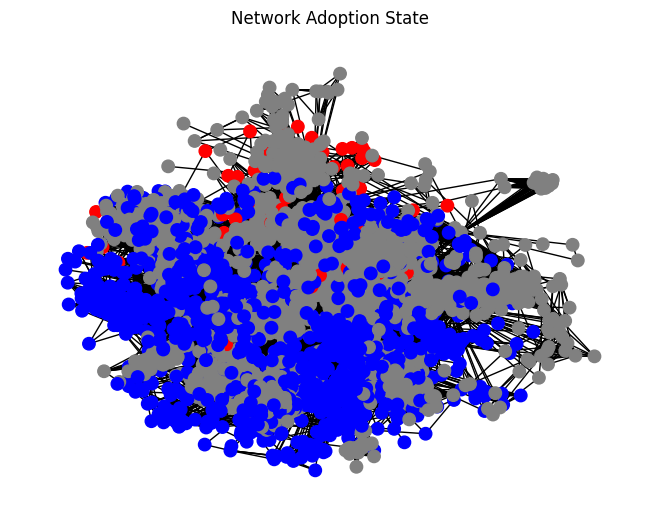

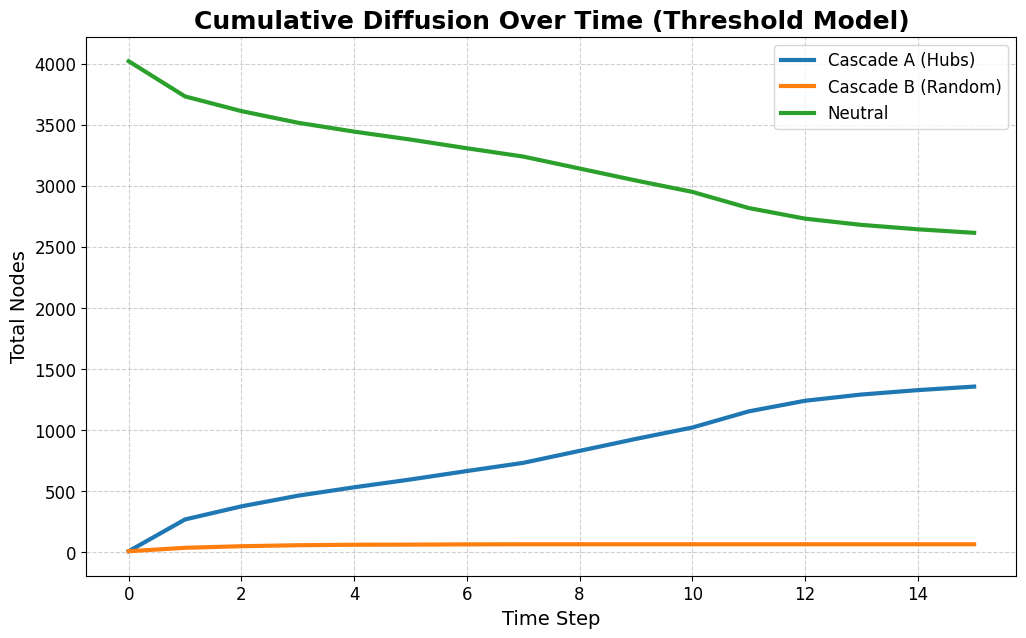

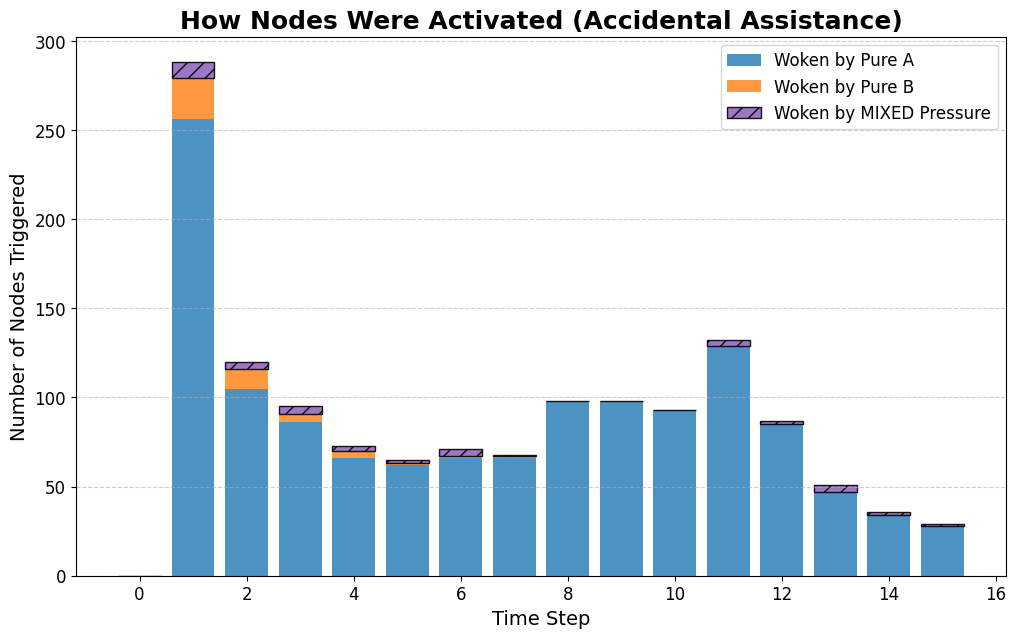

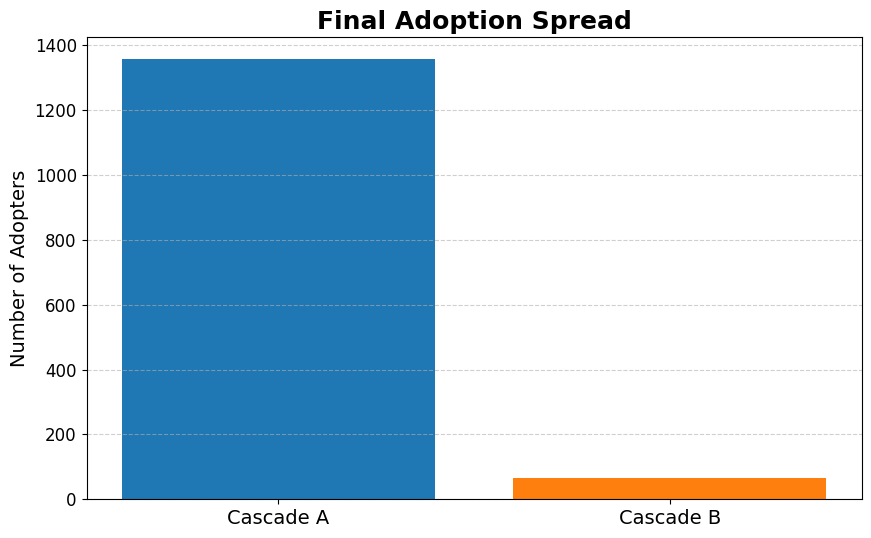

In [33]:
plot_network_state(G, model.states)
# --- Graph 1: Cumulative Diffusion ---
plt.figure(figsize=(12, 7))
plt.plot(steps, history['A'], label='Cascade A (Hubs)', color='#1f77b4', linewidth=3)
plt.plot(steps, history['B'], label='Cascade B (Random)', color='#ff7f0e', linewidth=3)
plt.plot(steps, history['Neutral'], label='Neutral', color='#2ca02c', linewidth=3)
plt.title('Cumulative Diffusion Over Time (Threshold Model)', fontsize=18, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Total Nodes', fontsize=14)
plt.xticks(fontsize=12); plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Graph 2: The "Wake-Up Call" Composition ---
plt.figure(figsize=(12, 7))
plt.bar(steps, history['Pure_A_Triggers'], label='Woken by Pure A', color='#1f77b4', alpha=0.8)
plt.bar(steps, history['Pure_B_Triggers'], bottom=history['Pure_A_Triggers'], label='Woken by Pure B', color='#ff7f0e', alpha=0.8)
mixed_bottom = [a + b for a, b in zip(history['Pure_A_Triggers'], history['Pure_B_Triggers'])]
plt.bar(steps, history['Mixed_Triggers'], bottom=mixed_bottom, label='Woken by MIXED Pressure', color='#9467bd', alpha=0.9, edgecolor='black', hatch='//')
plt.title('How Nodes Were Activated (Accidental Assistance)', fontsize=18, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Number of Nodes Triggered', fontsize=14)
plt.xticks(fontsize=12); plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --- Graph 3: Final Adoption Spread ---
plt.figure(figsize=(10, 6))
plt.bar(['Cascade A', 'Cascade B'], [history['A'][-1], history['B'][-1]], color=['#1f77b4', '#ff7f0e'])
plt.title('Final Adoption Spread', fontsize=18, fontweight='bold')
plt.ylabel('Number of Adopters', fontsize=14)
plt.xticks(fontsize=14); plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

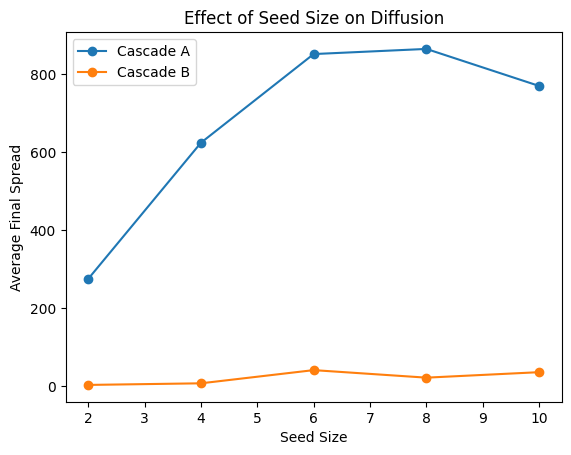

In [34]:
analyze_seed_sizes(G, CompetitiveWeightedThreshold, runs=15)

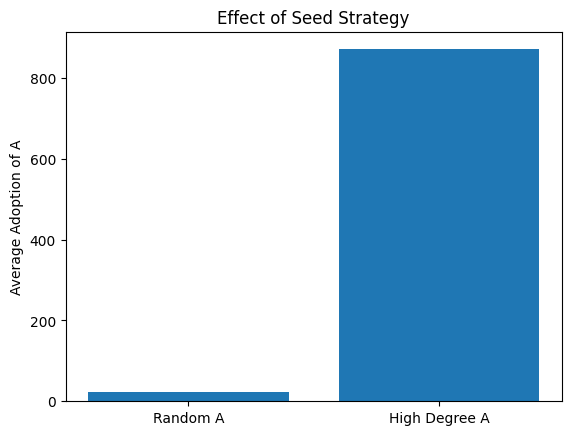

In [35]:
seed_strategies(G, CompetitiveWeightedThreshold, 10, runs=15)